# Class 25: LLMs

Plan for today:
- Clustering
- LLMs and Hugging Face


In [1]:
import YData

# YData.download.download_class_code(25)   # get class code    
# YData.download.download_class_code(25, TRUE) # get the code with the answers 

If you are using colabs, you should run the code below.

In [2]:
# !pip install https://github.com/yuejiechi/YData_package/tarball/master
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from urllib.request import urlopen

import matplotlib.pyplot as plt
%matplotlib inline

# Suppress ConvergenceWarning - please ignore this code 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Unsupervised learning: clustering

We can do k-means clustering in scikit-learn using the `KMeans()` object.


In [4]:
penguins = sns.load_dataset("penguins")

penguins = penguins.dropna()

penguins = penguins.sample(frac = 1)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
184,Chinstrap,Dream,42.5,16.7,187.0,3350.0,Female
15,Adelie,Torgersen,36.6,17.8,185.0,3700.0,Female
80,Adelie,Torgersen,34.6,17.2,189.0,3200.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
229,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,Male


In [5]:
# get the features and the labels

X_penguin_features = penguins[['bill_length_mm', 
                               'bill_depth_mm',
                               'flipper_length_mm']]

y_penguin = penguins['body_mass_g']


# also save the penguin species to use later
y_penguin_species = penguins['species']


In [6]:
from sklearn.cluster import KMeans

# fit k-means with 3 clusters 

kmeans = KMeans(n_clusters=3)
kmeans.fit(X_penguin_features)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [7]:
# see which cluster each point belongs to 

predicted_labels = kmeans.predict(X_penguin_features)
predicted_labels

array([1, 1, 1, 1, 0, 2, 1, 1, 2, 2, 2, 1, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 2, 2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 1, 1, 2, 1, 2, 1, 0,
       2, 0, 0, 0, 2, 2, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1, 2, 2, 1, 2, 1, 2,
       2, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 0, 1, 0, 0, 1, 1, 0, 2, 2, 0, 1,
       1, 1, 1, 0, 2, 0, 1, 2, 0, 2, 0, 1, 2, 2, 2, 0, 1, 0, 0, 2, 1, 0,
       2, 1, 0, 0, 0, 2, 1, 0, 1, 1, 2, 2, 0, 2, 1, 2, 2, 0, 2, 2, 0, 0,
       1, 1, 2, 2, 0, 0, 0, 0, 1, 2, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1,
       0, 0, 2, 1, 0, 0, 2, 0, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 2, 2, 2, 2,
       1, 0, 1, 1, 1, 2, 0, 1, 2, 1, 0, 1, 2, 0, 1, 0, 0, 1, 2, 1, 2, 1,
       1, 0, 0, 0, 1, 1, 2, 2, 1, 1, 0, 0, 0, 1, 2, 0, 0, 2, 1, 2, 2, 2,
       1, 0, 1, 0, 0, 1, 2, 0, 1, 2, 1, 2, 0, 0, 2, 2, 0, 1, 2, 1, 0, 0,
       2, 0, 1, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 1, 1, 1, 1, 1, 1, 1, 0, 2,
       0, 0, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 2, 1, 2, 2,
       1, 1, 1, 1, 2, 0, 2, 1, 0, 1, 1, 0, 0, 0, 1,

In [8]:
# look at a matrix of which penguin types end up in which cluster 

matrix = pd.DataFrame({'labels': predicted_labels, 
                       'species': y_penguin_species})

ct = pd.crosstab(matrix['labels'], matrix['species'])
print(ct)

species  Adelie  Chinstrap  Gentoo
labels                            
0             2          5     118
1           106          9       0
2            38         54       1


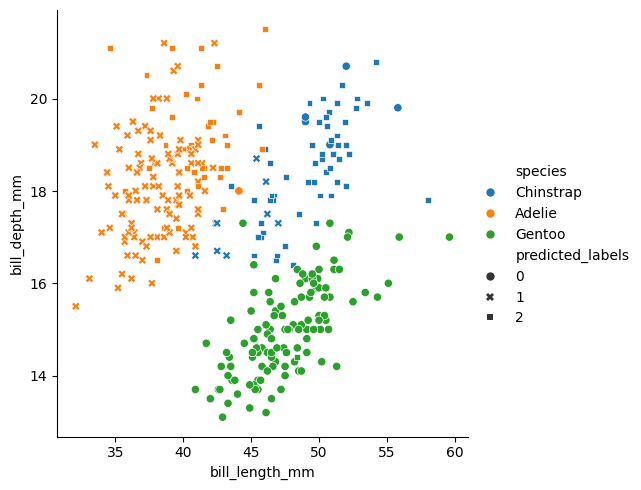

In [21]:
# visualize

penguins_updated = penguins
penguins_updated['predicted_labels'] = predicted_labels

sns.relplot(data = penguins_updated, 
            x = "bill_length_mm", 
            y = "bill_depth_mm",
            hue = "species",
            style = "predicted_labels");

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# do clustering with feature normalization 
scaler = StandardScaler()
pipeline = make_pipeline(scaler, kmeans)

pipeline.fit(X_penguin_features)

,steps,"[('standardscaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [10]:
# see which cluster each (normalized) point belongs to

predicted_labels2 = pipeline.predict(X_penguin_features)

predicted_labels2


array([0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 2, 0, 2, 0, 1,
       2, 1, 1, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 2, 0, 2, 0, 0,
       2, 0, 0, 0, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 0, 1, 1, 0, 0, 1,
       2, 0, 1, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1, 2, 0, 2, 2, 1, 2, 0, 1, 1,
       2, 0, 0, 2, 1, 1, 1, 1, 0, 2, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 0,
       2, 1, 2, 0, 1, 1, 2, 1, 2, 1, 1, 1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 2,
       0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 2, 1, 0, 2, 1, 0, 2, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 2, 2, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 2, 2, 2,
       0, 2, 0, 1, 1, 0, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 1, 0, 2, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 0, 1, 0, 0, 2, 0,
       0, 2, 0, 0, 2, 1, 2, 0, 1, 0, 2, 1, 1, 1, 0,

In [11]:
# look at a matrix of which penguin types end up in which cluster 

matrix_new = pd.DataFrame({'labels': predicted_labels2, 
                           'species': y_penguin_species})

ct_new = pd.crosstab(matrix_new['labels'], 
                     matrix_new['species'])
print(ct_new)

species  Adelie  Chinstrap  Gentoo
labels                            
0           141          5       0
1             0          0     119
2             5         63       0


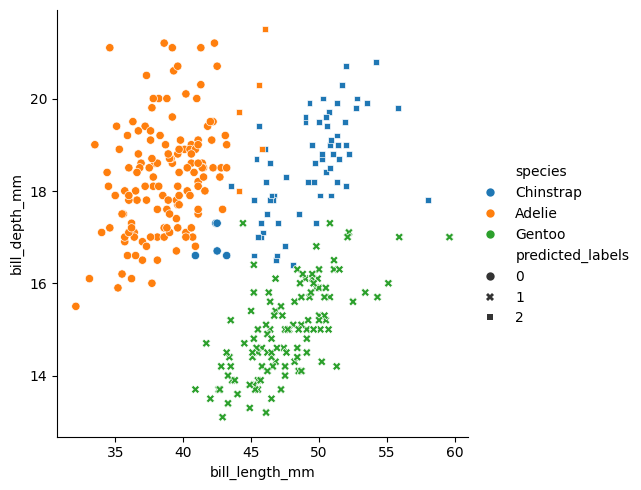

In [20]:
# visualize

penguins_updated = penguins
penguins_updated['predicted_labels'] = predicted_labels2

sns.relplot(data = penguins_updated, 
            x = "bill_length_mm", 
            y = "bill_depth_mm",
            hue = "species",
            style = "predicted_labels");

## Hierarchical clustering


In [12]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy

#  Ward's method adds points to a cluster that minimizes the sum of squared differences within all clusters
clusters = hierarchy.linkage(X_penguin_features, method="ward")   


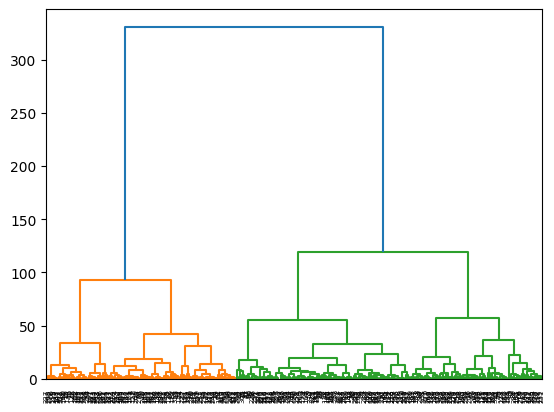

In [13]:
# display a dendrogram
dendrogram = hierarchy.dendrogram(clusters)

In [14]:
# cluster points into 3 clusters 
clustering_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
clustering_model.fit(X_penguin_features)

# get the predicted cluster for each point
labels = clustering_model.labels_

labels

array([2, 2, 2, 2, 0, 1, 2, 2, 1, 1, 1, 2, 2, 0, 0, 0, 1, 2, 2, 0, 0, 2,
       2, 2, 0, 0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 0, 2, 2, 2, 1, 2, 1, 2, 0,
       1, 0, 0, 0, 1, 1, 2, 2, 2, 0, 2, 2, 0, 0, 1, 2, 0, 1, 2, 1, 2, 1,
       1, 2, 2, 2, 0, 2, 0, 2, 0, 1, 0, 0, 2, 0, 0, 2, 2, 0, 1, 1, 0, 2,
       2, 2, 2, 0, 1, 0, 2, 1, 0, 1, 0, 2, 1, 1, 1, 0, 2, 0, 0, 1, 2, 0,
       1, 2, 0, 0, 0, 1, 2, 0, 2, 2, 1, 1, 0, 1, 2, 1, 1, 0, 1, 1, 0, 0,
       2, 2, 1, 1, 0, 0, 0, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 0, 2,
       0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       2, 0, 2, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 0, 2, 0, 0, 2, 1, 2, 1, 2,
       2, 0, 0, 0, 2, 2, 1, 1, 2, 2, 0, 0, 0, 2, 1, 0, 0, 1, 2, 1, 1, 1,
       2, 0, 2, 0, 0, 2, 1, 0, 2, 1, 2, 1, 0, 0, 1, 1, 0, 2, 1, 2, 0, 0,
       1, 0, 2, 2, 0, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 2, 2, 0, 1,
       0, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 1, 2, 1, 1,
       2, 2, 2, 2, 1, 0, 1, 2, 0, 2, 2, 0, 0, 0, 2,

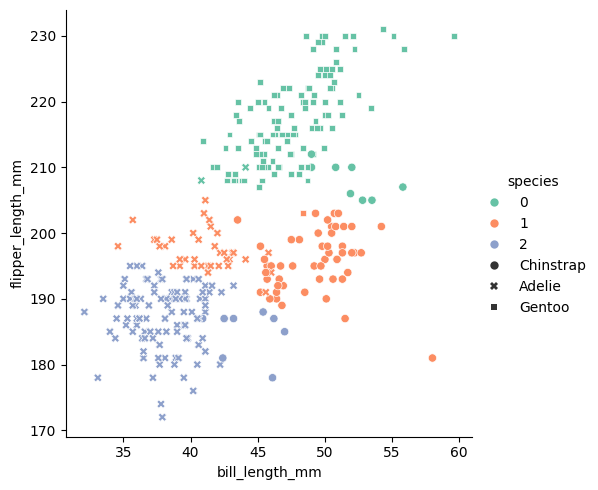

In [15]:
# visualize how well the clustering matches the penguin species

sns.relplot(X_penguin_features, 
            x='bill_length_mm', 
            y='flipper_length_mm', 
            hue=labels, 
            style = y_penguin_species,
            palette="Set2");


##  2. Large language models (LLMs)

Large language models (LLMs) are taking over the world. I, for one, welcome our new robot [overlords](https://www.youtube.com/watch?v=8lcUHQYhPTE).

Let's explore how we can use a model from Hugging Face to create a chatbot.

To do this we need to install some additional packages. I recommend cloning your Jupyter environment, and then adding these packages to the new environment.


In [16]:
## If you are using uv, you might need to uncomment the lines below to install the following packages
#!uv add torch
#!uv add transformers

In [ ]:
# Modified from code created by Giuliano Formisano
# Updated to work with new version of hugging face packages

from transformers import pipeline, BlenderbotTokenizer, BlenderbotForConditionalGeneration

model_name = "facebook/blenderbot-400M-distill"

# Option A: Using text2text-generation pipeline (single-turn):
chatbot = pipeline("text2text-generation", model=model_name, tokenizer=model_name, device = "cpu")

# This uses "mps" by default on my mac which should be faster but there appears to be a bug in the code
#chatbot = pipeline("text2text-generation", model=model_name, tokenizer=model_name)


user_input = "Hi! What can you do?"
response = chatbot(user_input, max_new_tokens=50)

print(f"User:  {user_input}")
print(f"Bot:   {response[0]['generated_text']}")



### Loop for an interaction User-Chatbot

In [ ]:
# Loop of interaction user-chatbot
while True:
  user_input = input("You: ") # add prompt in the appearing box below
  if user_input.lower() == "quit": # write "quit" to interrupt
    break
  response = chatbot(user_input) # this is a bit slow
  print(f"Chatbot: {response[0]['generated_text']}")

### Hugging Face data sets

In [ ]:
# Hugging Face also has a number of large/interesting data sets
# (some of them controversial, and of course, one should be cautious of the veracity of all data sets)

# Load a data set 

from datasets import load_dataset

#emails = load_dataset("tensonaut/EPSTEIN_FILES_20K", split="train")
emails = load_dataset("corbt/enron-emails", split="train")


# print type and shape
print(emails.shape)
print(type(emails))


# convert to a pandas data frame
emails_df = emails.to_pandas()

display(emails_df.head())


In [ ]:
# search for keywords
emails_containing = "summers" 

column_name = "body"  
#column_name = "text"  


# rfind returns first index where word occurs
selected_emails = emails_df[(emails_df[column_name].str.lower().str.rfind(emails_containing) > 0)]


print(selected_emails.shape)
display(selected_emails.head())

print(selected_emails.iloc[0][column_name])